In [1]:
%load_ext autoreload
%autoreload 2

# 4D SfM Pipeline

Processes one new day at a time through the full 4D SfM workflow:

1. **Multi-temporal BA** — reference cameras fixed (0.001), new day cameras loose (0.5 m / 5°)
2. **Single-day re-run** — IOP fixed from step 1, EOP loose, generates point cloud
3. **Co-registration** — ASP `pc_align` against the fixed initial reference cloud
4. **Apply transform** — transform applied to single-day camera positions
5. **Update Metashape** — co-registered positions imported into the single-day `.psx`
6. **Validation** — rebuild point cloud from co-registered cameras, M3C2 against Step 3b stable TBA (near-zero → transform propagated correctly)
7. **Update registry** — validated EOP + IOP path appended to `reference_registry.csv`

In [1]:
import os
os.environ["AGISOFT_LICENSE_PATH"] = "/home/asus/.config/Agisoft/license.lic"

import Metashape
import cntp
import sys
sys.path.insert(0, str(__import__('pathlib').Path('../../contributors/umayr').resolve()))
import tools

from pathlib import Path
import numpy as np
import pandas as pd

from cntp.metashape import (
    discover_images,
    run_multitemporal_ba,
    run_single_day_fixed_iop,
    update_metashape_cameras_after_transform,
    update_registry,
    _utm_epsg,
)
from tools import (
    pc_align_p2p_sp2p,
    extract_stable_reference,
    evaluate_coreg,
    apply_coreg_to_cameras_ecef,
    _read_asp_transform,
)

## Configuration
Set all paths and parameters here. Everything below runs without further edits.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
base_dir     = Path("/mnt/g/2023_11_Nepal/2023_Changri")
tlcam_dir    = base_dir / "TLCAM"
output_dir   = base_dir

# Fixed initial reference point cloud — never changes across all days
ref_cloud    = base_dir / "Ref_PC" / "Reference_UAV_TLC_PCS.laz"

# Glacier mask shapefile (UTM) — used for stable terrain filtering in Stage 3
glacier_mask = base_dir / "glaciermask_new" / "glacier_mask_pcs.shp"

# Registry — must already exist (run bootstrap_registry.ipynb first)
registry_csv = output_dir / "output_new" / "reference_registry.csv"

# ── Date to process ───────────────────────────────────────────────────────
new_date = "2023-12-15"   # <-- change this for each new day

# ── BA parameters ─────────────────────────────────────────────────────────
match_downscale = 0    # 0, 1, 2, 3 = resolution
depth_downscale = 2    # 0, 1, 2, 3 = resolution

# Accuracy for new-day cameras in multi-temporal BA and single-day re-run
loc_acc_new = (0.5, 0.5, 0.5)   # metres
rot_acc_new = (5.0, 5.0, 5.0)   # degrees

# Co-registration parameters
ref_downsample  = 0.4
tba_downsample  = 1.0
p2p_max_disp    = 10
sp2p_max_disp   = 5
m_sp2p_max_disp = 2

# ── Co-registration coordinate space ──────────────────────────────────────
# True  → clouds converted UTM→ECEF before pc_align; transform applied
#          to cameras as WGS84→ECEF→T→ECEF→WGS84
# False → clouds passed to pc_align in UTM; transform applied to cameras
#          as WGS84→UTM→T→UTM→WGS84
use_ecef = True

# ── Derived from registry ─────────────────────────────────────────────────
df_reg   = pd.read_csv(registry_csv)
utm_epsg = _utm_epsg(df_reg["lon"].mean())
print(f"UTM EPSG         : {utm_epsg}")
print(f"Registry entries : {df_reg['date'].nunique()} days, {len(df_reg)} images total")
print(f"Co-reg mode      : {'ECEF' if use_ecef else 'UTM'}")

UTM EPSG         : 32645
Registry entries : 1 days, 20 images total
Co-reg mode      : ECEF


## Discover images for the new day

In [4]:
by_date     = discover_images(tlcam_dir)
date_images = by_date.get(new_date)

if date_images is None:
    raise ValueError(f"No images found for {new_date} under {tlcam_dir}")

for cam, paths in date_images.items():
    print(f"  {cam} : {len(paths)} images")

  C1 : 9 images
  C2 : 9 images
  C3 : 9 images
  C4 : 8 images
  C5 : 9 images


## Step 1 — Multi-temporal bundle adjustment

- All reference cameras (from registry) held fixed at accuracy **0.001**
- New-day cameras initialised with mean EOP of the last registry day per camera group, accuracy **0.5 m / 5°**
- Each reference day gets its own fixed sensor per camera (preserves per-day IOP)
- New-day sensors: IOP floating, initialised from last registry day's refined calibration

Outputs → `output_new/YYYY-MM-DD/4D_SfM/`

In [5]:
cameras_4dsfm_csv, calib_4dsfm_dir = run_multitemporal_ba(
    date                   = new_date,
    date_images            = date_images,
    reference_registry_csv = registry_csv,
    output_dir             = output_dir,
    utm_epsg               = utm_epsg,
    match_downscale        = match_downscale,
    loc_acc_new            = loc_acc_new,
    rot_acc_new            = rot_acc_new,
)

print(f"\nCameras CSV : {cameras_4dsfm_csv}")
print(f"Calib dir   : {calib_4dsfm_dir}")


  4D SfM BA : 2023-12-15   (44 new images, 20 reference images)
SaveProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/4D_SfM/2023-12-15_4DSfM.psx
saved project in 0.08387 sec
LoadProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/4D_SfM/2023-12-15_4DSfM.psx
loaded project in 0.02318 sec
AddPhotos
AddPhotos
  Added 20 reference + 44 new-day images
  Sensors : 1 ref days × 5 cameras (fixed IOP) + 5 new (floating IOP)
  Reference cameras (tight 0.001) : 20/20
  New-day cameras  (loose 0.5 m / 5.0°) : 44/44
  Matching photos ...
MatchPhotos: downscale = 0, generic_preselection = on, reference_preselection = on, filter_mask = off, mask_tiepoints = on, filter_stationary_points = on, keypoint_limit = 40000, keypoint_limit_per_mpx = 1000, tiepoint_limit = 4000, guided_matching = off, exclude_corners = off
saved matching data in 0.011318 sec
saved object list in 0.004857 sec
scheduled 4 keypoint detection groups
saved keypoint partition in 0.004951 se

Can't load OpenCL library
failed to enable cpu vulkan support (/home/asus/miniconda3/envs/cntp/bin/lib dir not exists)


Found 1 GPUs in 1.40887 sec (CUDA: 1.31816 sec, OpenCL: 0.00021 sec, Vulkan: 0.090378 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 0: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 20: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 24: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 28: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 7: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 32: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 36: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 10: 40000 points
[GPU] processing 

Can't load OpenCL library


[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 1: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 21: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 25: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 4: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 29: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 33: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 37: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 11: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 41: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 45: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 14: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 49: 40000 p

...

810800 matches found in 0.618303 sec
matches combined in 0.052597 sec
filtered 106406 out of 445785 matches (23.8694%) in 0.11162 sec
saved matches in 0.053805 sec
loaded matching data in 0.002877 sec
loaded matching partition in 0.002478 sec
loaded object list in 0.001882 sec
loaded matches in 0.018219 sec
1791 pairs selected in 0.000199 sec
setting point indices... 17789 done in 0.001745 sec
setting point indices... 15816 done in 0.002063 sec
setting point indices... 15660 done in 0.001473 sec
150 skeletal pairs selected in 0.011608 sec
groups: 75 75
90 of 64 used (140.625%)
scheduled 2 keypoint matching groups
saved matching partition in 0.011634 sec
loaded object list in 0.00225 sec
loaded matching partition in 0.002775 sec
loaded keypoint partition in 0.003029 sec
loaded matching data in 0.002267 sec
loaded keypoints in 0.914552 sec


Can't load OpenCL library


Found 1 GPUs in 0.000681 sec (CUDA: 2.4e-05 sec, OpenCL: 0.000342 sec, Vulkan: 0.000268 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
644307 matches found in 6.69099 sec
matches combined in 0.053701 sec
filtered 54220 out of 336998 matches (16.0891%) in 0.223013 sec
saved matches in 0.080147 sec
loaded object list in 0.002451 sec
loaded matching partition in 0.003012 sec
loaded keypoint partition in 0.003408 sec
loaded matching data in 0.001977 sec
loaded keypoints in 0.78755 sec


Can't load OpenCL library


Found 1 GPUs in 0.000742 sec (CUDA: 2.6e-05 sec, OpenCL: 0.000385 sec, Vulkan: 0.000295 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
873863 matches found in 6.75926 sec
matches combined in 0.078787 sec
filtered 49391 out of 448835 matches (11.0043%) in 0.276494 sec
saved matches in 0.090748 sec
loaded matching data in 0.002342 sec
loaded object list in 0.002118 sec
loaded matching partition in 0.003113 sec
loaded keypoint partition in 0.002998 sec
loaded matches in 0.034818 sec
setting point indices... 206685 done in 0.041243 sec
generated 206685 tie points, 3.75975 average projections
removed 13978 multiple indices
removed 200 tracks
removing stationary tracks...
removed 170306 tracks
selected 36179 tracks out of 36179 in 0.005741 sec
loaded keypoint partition in 0.002603 sec
loaded matching partition in 0

## Step 2 — Single-day re-run with fixed IOP

- IOP fixed from Step 1 (`adjusted_calib_4DSfM/`)
- EOP loose (same accuracy as Step 1: 0.5 m / 5°), priors from `cameras_4DSfM.csv`
- Generates the point cloud for co-registration

Outputs → `output_new/YYYY-MM-DD/single_day/`

In [6]:
laz_path, cameras_single_csv = run_single_day_fixed_iop(
    date            = new_date,
    date_images     = date_images,
    calib_dir       = calib_4dsfm_dir,
    cameras_csv     = cameras_4dsfm_csv,
    output_dir      = output_dir,
    utm_epsg        = utm_epsg,
    match_downscale = match_downscale,
    depth_downscale = depth_downscale,
    loc_acc         = loc_acc_new,
    rot_acc         = rot_acc_new,
)

print(f"\nPoint cloud : {laz_path}")
print(f"Cameras CSV : {cameras_single_csv}")


  Single-day BA (fixed IOP) : 2023-12-15   (44 images)
SaveProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/single_day/2023-12-15.psx
saved project in 0.060759 sec
LoadProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/single_day/2023-12-15.psx
loaded project in 0.021732 sec
AddPhotos
  Added 44 photos
  Configured 5 sensors (IOP fixed)
  Set references from CSV : 44/44 cameras matched
  EOP priors (loose 0.5 m / 5.0°) : 44/44
  Matching photos ...
MatchPhotos: downscale = 0, generic_preselection = on, reference_preselection = on, filter_mask = off, mask_tiepoints = on, filter_stationary_points = on, keypoint_limit = 40000, keypoint_limit_per_mpx = 1000, tiepoint_limit = 4000, guided_matching = off, exclude_corners = off
saved matching data in 0.010534 sec
saved object list in 0.004441 sec
scheduled 3 keypoint detection groups
saved keypoint partition in 0.004238 sec
groups: 946
44 of 44 used (100%)
scheduled 1 keypoint matching groups
saved

Can't load OpenCL library


[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 0: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 3: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 6: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 9: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 12: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 15: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 18: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 21: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 24: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 27: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 30: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 33: 40000 poi

Can't load OpenCL library


[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 1: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 4: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 7: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 10: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 13: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 16: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 19: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 22: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 25: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 28: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 31: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 34: 40000 po

...

group 1/1: cameras images prepared in 6.00992 s
group 1/1: 44 x frame
group 1/1: 44 x uint8
group 1/1: expected peak VRAM usage: 945 MB (404 MB max alloc, 6512x7326 mipmap texture, 14 max neighbors)
Found 1 GPUs in 0.00367 sec (CUDA: 1.5e-05 sec, OpenCL: 0.002738 sec, Vulkan: 0.000886 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
Using device 'NVIDIA GeForce RTX 3050 Ti Laptop GPU' in concurrent. (2 times)
[GPU 1] group 1/1: estimating depth map for 1/44 camera 0 (3 neighbs)...
[GPU 2] group 1/1: estimating depth map for 2/44 camera 1 (3 neighbs)...


Can't load OpenCL library


[GPU 2] Camera 1 samples after final filtering: 14% (0.926682 avg inliers) = 100% - 29% (not matched) - 30% (bad matched) - 5% (no neighbors) - 7% (no cost neighbors) - 8% (inconsistent normal) - 0% (estimated bad angle) - 0% (found bad angle) - 7% (speckles filtering)
[GPU 2] Camera 1 tile #1/4: level #6/6 (x2 downscale: 1664x1280, image blowup: 3328x2560) done in 0.990217 s = 46% propagation + 39% refinement + 6% filtering + 0% smoothing
Peak VRAM usage updated: Camera 1 (3 neihbs): 155 MB = 45 MB gpu_neighbImages (29%) + 20 MB gpu_mipmapNeighbImage (13%) + 12 MB gpu_tmp_normal (8%) + 12 MB gpu_tmp_hypo_ni_cost (8%) + 8 MB gpu_refImage (5%) + 8 MB gpu_depth_map (5%) + 8 MB gpu_cost_map (5%) + 8 MB gpu_coarse_depth_map_radius (5%) + 8 MB gpu_coarse_depth_map (5%) + 6 MB gpu_normal_map (4%)
[GPU 1] Camera 0 samples after final filtering: 15% (0.843659 avg inliers) = 100% - 27% (not matched) - 31% (bad matched) - 5% (no neighbors) - 5% (no cost neighbors) - 9% (inconsistent normal) - 0%

Can't load OpenCL library


Camera 1 (3 neighbs) level #1/3 filtering: 2% good (3% of speckles) + 4% norm (97% of speckles) - 0% speckles + 5% bad + 90% empty (22% inliers support + 5% inliers intersects + 3% inliers doesn't reach + 25% inliers no depth + 39% outliers support + 7% outliers intersects + 8% outliers doesn't reach + 2% inliers occludes + 5% outliers occludes)
Camera 1 (3 neighbs) level #2/3 filtering: 4% good (2% of speckles) + 7% norm (98% of speckles) - 0% speckles + 9% bad + 80% empty (24% inliers support + 4% inliers intersects + 2% inliers doesn't reach + 24% inliers no depth + 40% outliers support + 6% outliers intersects + 7% outliers doesn't reach + 7% inliers occludes + 12% outliers occludes)
Camera 1 (3 neighbs) level #3/3 filtering: 6% good (4% of speckles) + 10% norm (96% of speckles) - 0% speckles + 8% bad + 76% empty (33% inliers support + 3% inliers intersects + 2% inliers doesn't reach + 13% inliers no depth + 45% outliers support + 6% outliers intersects + 6% outliers doesn't reach 

## Step 3 — Co-registration against the initial reference cloud

Three-stage ASP ICP (point-to-plane → similarity-p2p → similarity-p2p on stable terrain).
The **reference cloud never changes** across all days — it defines the absolute coordinate frame.

Outputs → `output_new/YYYY-MM-DD/coreg/`

In [3]:
coreg_dir = output_dir / "output_new" / new_date / "coreg"

# Derived from Step 2 outputs — safe to re-derive after a kernel restart.
laz_path           = output_dir / "output_new" / new_date / "single_day" / f"{new_date}_cloud.laz"
cameras_single_csv = output_dir / "output_new" / new_date / "single_day" / f"{new_date}_cameras.csv"

# Pre-downsample the reference cloud once and save to disk.
# extract_stable_reference receives the downsampled copy (not the full cloud)
# so only ref_downsample × full-cloud is ever in Python memory.
# pc_align_p2p_sp2p reuses this cached file and skips re-downsampling.
ds_dir      = coreg_dir / "downsampled"
ds_dir.mkdir(parents=True, exist_ok=True)
ref_ds_path = ds_dir / f"{ref_cloud.stem}_ds{ref_downsample:.2f}.las"
if not ref_ds_path.exists():
    print(f"  Saving downsampled reference ({ref_downsample:.0%}) → {ref_ds_path.name}")
    from cntp.io import load_las, save_las
    save_las(load_las(ref_cloud, downsample_factor=ref_downsample), ref_ds_path)

# Build glacier-masked stable terrain reference for Stage 3.
# Returns (stable_path, slope_path) — slope_path is the pre-filter cloud
# used for reference diagnostic plots in Step 3b without recomputation.
stable_ref, ref_slope_path = extract_stable_reference(
    ref_cloud_path    = ref_ds_path,
    output_dir        = coreg_dir / "stable_ref",
    glacier_mask_path = glacier_mask,
)

# use_ecef=True  → clouds converted UTM→ECEF before pc_align (true Cartesian ICP)
# use_ecef=False → clouds passed to pc_align in flat UTM
aligned_las, transform_path = pc_align_p2p_sp2p(
    tba_las                 = laz_path,
    ref_las                 = ref_cloud,
    output_dir              = coreg_dir,
    stable_ref_las          = stable_ref,
    p2p_max_displacement    = p2p_max_disp,
    sp2p_max_displacement   = sp2p_max_disp,
    m_sp2p_max_displacement = m_sp2p_max_disp,
    ref_downsample_factor   = ref_downsample,
    tba_downsample_factor   = tba_downsample,
    utm_epsg                = utm_epsg if use_ecef else None,
    verbose                 = True,
)

print(f"\nAligned cloud  : {aligned_las}")
print(f"Transform file : {transform_path}")

  Saving downsampled reference (40%) → Reference_UAV_TLC_PCS_ds0.40.las
  Stable reference → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stable_ref/Reference_UAV_TLC_PCS_ds0.40_stable.las  (1,003,149 pts)
  Saving TBA (full) → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/downsampled/2023-12-15_cloud_full.las
  Stage 1 — point-to-plane ICP (max_displacement=10 m)
pc_align --threads 16 --max-displacement 10 --alignment-method point-to-plane -o /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/run /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/ecef/Reference_UAV_TLC_PCS_ds0.40_ecef.las /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/ecef/2023-12-15_cloud_full_ecef.las
	--> Setting number of processing threads to: 16
Writing log: /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/run-log-pc_align-05-17-0007-10927.txt
No datum specified. Will write output CSV files in the x,y,z

## Step 3b — Co-registration accuracy (M3C2 on stable terrain)

M3C2 distances computed on glacier-masked, slope-filtered stable terrain before and after
co-registration. Stable TBA cloud saved to `coreg/stable_tba/`, plots to `coreg/m3c2_plots/`.

In [4]:
coreg_stats = evaluate_coreg(
    ref_las               = ref_ds_path,
    tba_before_las        = laz_path,
    tba_after_las         = aligned_las,
    ref_downsample_factor = 1.0,
    glacier_mask_path     = glacier_mask,
    stable_dir            = coreg_dir / "stable_tba",
    plot_dir              = coreg_dir / "m3c2_plots",
    stable_ref_las        = stable_ref,
    ref_slope_las         = ref_slope_path,
)

print(f"\nMedian M3C2 before : {coreg_stats['med_before']:.4f} m")
print(f"Median M3C2 after  : {coreg_stats['med_after']:.4f} m")

[2026-05-17 00:19:04][INFO] Building KDTree structure with leaf parameter 10
[2026-05-17 00:19:04][INFO] Building KDTree structure with leaf parameter 10
[2026-05-17 00:19:57][INFO] Building KDTree structure with leaf parameter 10
  Before — median M3C2: -1.0332 m  std: 1.1676 m
  After  — median M3C2: -0.0147 m  std: 1.0559 m
  Stable TBA (after)  : /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stable_tba/2023-12-15_cloud_coreg_hsfm_stable.laz

Median M3C2 before : -1.0332 m
Median M3C2 after  : -0.0147 m


## Step 4 — Apply co-registration transform to camera positions

Transforms the single-day camera positions (WGS84 → ECEF → T → ECEF → WGS84).

In [5]:
cameras_coreg_csv = coreg_dir / f"{new_date}_cameras_coreg.csv"

# use_ecef=True  → WGS84→ECEF→T→ECEF→WGS84  (matches ECEF pc_align transform)
# use_ecef=False → WGS84→UTM→T→UTM→WGS84    (matches UTM pc_align transform)
apply_coreg_to_cameras_ecef(
    cameras_csv    = cameras_single_csv,
    transform_path = transform_path,
    out_csv        = cameras_coreg_csv,
    utm_epsg       = None if use_ecef else utm_epsg,
)

print(f"Co-registered cameras → {cameras_coreg_csv}")

Saved transformed cameras → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/2023-12-15_cameras_coreg.csv
Co-registered cameras → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/2023-12-15_cameras_coreg.csv


## Step 5 — Verify transform inputs

Confirms the ASP Stage 3 transform file and PSX exist, and prints the expected shift magnitude.
The transform is applied in Step 6 (same Metashape session as the cloud rebuild).

In [6]:
# Verify inputs for Step 6 and preview the expected shift
transform_path = coreg_dir / "stage3" / "run-transform.txt"
single_day_psx = output_dir / "output_new" / new_date / "single_day" / f"{new_date}.psx"

print(f"transform_path : {transform_path.exists()} — {transform_path.name}")
print(f"single_day_psx : {single_day_psx.exists()} — {single_day_psx.name}")

T_ecef = _read_asp_transform(transform_path)
print(f"\nASP ECEF transform translation magnitude : {np.linalg.norm(T_ecef[:3, 3]):.4f} m")
print(T_ecef)

transform_path : True — run-transform.txt
single_day_psx : True — 2023-12-15.psx

ASP ECEF transform translation magnitude : 19280.9570 m
[[ 9.97707089e-01 -6.48173063e-04  9.27435564e-04  1.61800321e+03]
 [ 6.50050712e-04  9.97705472e-01 -2.02104785e-03  1.87343119e+04]
 [-9.26120466e-04  2.02165082e-03  9.97705253e-01 -4.26179872e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Step 6 — Validation

Rebuilds the point cloud from the co-registered cameras, extracts stable terrain from it,
then computes M3C2 distances against the stable TBA saved in Step 3b.

Near-zero M3C2 distances confirm the ASP transform was correctly propagated through the
camera positions into the Metashape-rebuilt point cloud.

In [7]:
# Open PSX, apply ECEF transform, build cloud — all in one session so the
# matrix fix is never lost to a save/reload cycle.
import math

doc = Metashape.Document()
doc.clear()
doc.open(str(single_day_psx), read_only=False, ignore_lock=True)
chunk = doc.chunk

def _cam_wgs84(chunk):
    cam = next((c for c in chunk.cameras if c.transform), None)
    if cam is None:
        return None, None
    p = chunk.crs.project(chunk.transform.matrix.mulp(cam.center))
    return cam.label, (p[0], p[1], p[2])

def _shift_m(p0, p1):
    dlat = (p1[1]-p0[1])*111_320
    dlon = (p1[0]-p0[0])*111_320*math.cos(math.radians((p0[1]+p1[1])/2))
    return (dlat**2 + dlon**2 + (p1[2]-p0[2])**2)**0.5

lbl, p0 = _cam_wgs84(chunk)
print(f"  [{lbl}] ON LOAD : alt={p0[2]:.3f} m")

# Apply T_ecef @ M_old directly — chunk.transform.matrix maps local→ECEF (WGS84 geocentric),
# same space as the ASP transform, so no CRS conversion needed.
M_old = chunk.transform.matrix
M_np  = np.array([[M_old[r, c] for c in range(4)] for r in range(4)])
M_new = T_ecef @ M_np
chunk.transform.matrix = Metashape.Matrix(
    [[float(M_new[r, c]) for c in range(4)] for r in range(4)]
)

lbl, p1 = _cam_wgs84(chunk)
print(f"  [{lbl}] AFTER T : alt={p1[2]:.3f} m  shift={_shift_m(p0, p1):.4f} m")

# Build depth maps and point cloud in the same session (matrix stays applied)
print("  Building depth maps ...")
chunk.buildDepthMaps(downscale=depth_downscale, filter_mode=Metashape.MildFiltering)

print("  Building point cloud ...")
chunk.buildPointCloud()

_, p2 = _cam_wgs84(chunk)
print(f"  [{lbl}] AFTER buildPointCloud : alt={p2[2]:.3f} m  shift from T={_shift_m(p1, p2):.4f} m")

val_dir = output_dir / "output_new" / new_date / "single_day" / "validation"
val_dir.mkdir(parents=True, exist_ok=True)
validated_laz = val_dir / f"{new_date}_cloud_validated.laz"

utm_crs = Metashape.CoordinateSystem(f"EPSG::{utm_epsg}")
chunk.exportPointCloud(
    str(validated_laz),
    source_data      = Metashape.PointCloudData,
    format           = Metashape.PointCloudFormatLAS,
    crs              = utm_crs,
    save_point_color = True,
)
doc.save()
print(f"  Validation cloud → {validated_laz.name}")

LoadProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/single_day/2023-12-15.psx
loaded project in 0.036717 sec
  [C1_2023-12-15_090001] ON LOAD : alt=5490.345 m
  [C1_2023-12-15_090001] AFTER T : alt=5489.077 m  shift=1.7034 m
  Building depth maps ...
BuildDepthMaps: downscale = 2, filter_mode = Mild, reuse_depth = off
Preparing 44 cameras info...
sorting tie points... done in 0.034316 sec
cameras data loaded in 0.004293 s
cameras graph built in 0.000916 s
filtering neighbors with too low common points, threshold=50...
avg neighbors before -> after filtering: 35.5455 -> 6.90909 (81% filtered out)
limiting neighbors to 16 best...
avg neighbors before -> after filtering: 6.90909 -> 6.90909 (0% filtered out)
neighbors number min/1%/10%/median/90%/99%/max: 1, 1, 3, median=6, 13, 14, 14
cameras info prepared in 0.050475 s
saved cameras info in 0.023182
Partitioning 44 cameras...
number of mini clusters: 1
1 groups: avg_ref=44 avg_neighb=0 total_io=100%
max_ref=44 max_

Can't load OpenCL library
failed to enable cpu vulkan support (/home/asus/miniconda3/envs/cntp/bin/lib dir not exists)


Found 1 GPUs in 1.55318 sec (CUDA: 1.28021 sec, OpenCL: 0.000641 sec, Vulkan: 0.272293 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
  got device properties in 0.000126 sec, free memory in 0.521287 sec
group 1/1: cameras images prepared in 7.85364 s
group 1/1: 44 x frame
group 1/1: 44 x uint8
group 1/1: expected peak VRAM usage: 945 MB (404 MB max alloc, 6512x7326 mipmap texture, 14 max neighbors)
Found 1 GPUs in 0.001213 sec (CUDA: 2.6e-05 sec, OpenCL: 0.000726 sec, Vulkan: 0.000425 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
Using device 'NVIDIA GeForce RTX 3050 Ti Laptop GPU' in concurrent. (2 times)
[GPU 1] group 1/1: estima

Can't load OpenCL library


[GPU 1] Camera 0 samples after final filtering: 15% (0.843659 avg inliers) = 100% - 27% (not matched) - 31% (bad matched) - 5% (no neighbors) - 5% (no cost neighbors) - 9% (inconsistent normal) - 0% (estimated bad angle) - 0% (found bad angle) - 8% (speckles filtering)
[GPU 1] Camera 0 tile #1/4: level #6/6 (x2 downscale: 1664x1280, image blowup: 3328x2560) done in 0.997856 s = 46% propagation + 39% refinement + 6% filtering + 0% smoothing
Peak VRAM usage updated: Camera 0 (3 neihbs): 156 MB = 47 MB gpu_neighbImages (30%) + 19 MB gpu_mipmapNeighbImage (13%) + 12 MB gpu_tmp_normal (8%) + 12 MB gpu_tmp_hypo_ni_cost (8%) + 8 MB gpu_refImage (5%) + 8 MB gpu_depth_map (5%) + 8 MB gpu_cost_map (5%) + 8 MB gpu_coarse_depth_map_radius (5%) + 8 MB gpu_coarse_depth_map (5%) + 6 MB gpu_normal_map (4%)
[GPU 2] Camera 1 samples after final filtering: 14% (0.926682 avg inliers) = 100% - 29% (not matched) - 30% (bad matched) - 5% (no neighbors) - 7% (no cost neighbors) - 8% (inconsistent normal) - 0%

Can't load OpenCL library


Camera 1 (3 neighbs) level #1/3 filtering: 2% good (3% of speckles) + 4% norm (97% of speckles) - 0% speckles + 5% bad + 90% empty (22% inliers support + 6% inliers intersects + 3% inliers doesn't reach + 23% inliers no depth + 39% outliers support + 8% outliers intersects + 8% outliers doesn't reach + 2% inliers occludes + 5% outliers occludes)
Camera 1 (3 neighbs) level #2/3 filtering: 4% good (2% of speckles) + 7% norm (98% of speckles) - 0% speckles + 9% bad + 80% empty (24% inliers support + 5% inliers intersects + 2% inliers doesn't reach + 23% inliers no depth + 40% outliers support + 6% outliers intersects + 7% outliers doesn't reach + 7% inliers occludes + 13% outliers occludes)
Camera 1 (3 neighbs) level #3/3 filtering: 6% good (4% of speckles) + 10% norm (96% of speckles) - 0% speckles + 8% bad + 76% empty (33% inliers support + 3% inliers intersects + 2% inliers doesn't reach + 12% inliers no depth + 45% outliers support + 5% outliers intersects + 6% outliers doesn't reach 

  Stable validated cloud → 2023-12-15_cloud_validated_stable.laz  (199,931 pts)
[2026-05-17 00:29:53][INFO] Building KDTree structure with leaf parameter 10
[2026-05-17 00:29:53][INFO] Building KDTree structure with leaf parameter 10

M3C2 median : -0.0017 m  (near-zero → transform propagated correctly)
M3C2 std    : 0.3832 m


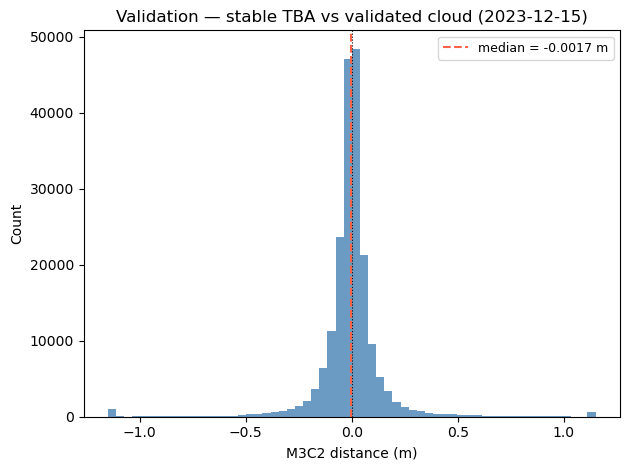

In [8]:
import py4dgeo
import matplotlib.pyplot as plt
from cntp.io import load_las, save_las, apply_glacier_mask
from cntp.coreg import extract_stable_terrain, run_m3c2

val_dir = output_dir / "output_new" / new_date / "single_day" / "validation"

# stable TBA from Step 3b — aligned_las after glacier mask + slope/NDWI filter
stable_tba_path = coreg_dir / "stable_tba" / f"{aligned_las.stem}_stable.laz"

# Extract stable terrain from the validated cloud
val_cloud = load_las(validated_laz)
val_cloud = apply_glacier_mask(val_cloud, glacier_mask)
_, val_stable = extract_stable_terrain(val_cloud)

val_stable_path = val_dir / f"{new_date}_cloud_validated_stable.laz"
save_las(val_stable, val_stable_path)
print(f"  Stable validated cloud → {val_stable_path.name}  ({len(val_stable):,} pts)")

# M3C2 between stable_tba (Step 3b) and stable validated cloud
stable_tba_cloud = load_las(stable_tba_path)
epoch_ref = py4dgeo.Epoch(stable_tba_cloud[:, :3])
epoch_val = py4dgeo.Epoch(val_stable[:, :3])

med, std, dist = run_m3c2(epoch_ref, epoch_val)
print(f"\nM3C2 median : {med:.4f} m  (near-zero → transform propagated correctly)")
print(f"M3C2 std    : {std:.4f} m")

# Plot
val_plot_dir = val_dir / "validation_plots"
val_plot_dir.mkdir(parents=True, exist_ok=True)

d = dist[~np.isnan(dist)]
clip = 3 * np.std(d)
d = np.clip(d, -clip, clip)

fig, ax = plt.subplots()
ax.hist(d, bins=60, color="steelblue", alpha=0.8)
ax.axvline(float(np.median(d)), color="tomato", linestyle="--", linewidth=1.5,
           label=f"median = {np.median(d):.4f} m")
ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("M3C2 distance (m)")
ax.set_ylabel("Count")
ax.set_title(f"Validation — stable TBA vs validated cloud ({new_date})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(val_plot_dir / "m3c2_validation.png", dpi=150)
plt.show()

## Step 7 — Update reference registry

Appends the validated day's co-registered EOP and IOP path to `reference_registry.csv`.
The next day's run will automatically pick this up as a reference.

In [ ]:
update_registry(
    registry_csv      = registry_csv,
    date              = new_date,
    date_images       = date_images,
    cameras_coreg_csv = cameras_coreg_csv,
    calib_dir         = calib_4dsfm_dir,
)

print(f"\nRegistry : {registry_csv}")
pd.read_csv(registry_csv).groupby("date").size().reset_index(name="n_images")